In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

In [3]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [5]:
matches.shape
deliveries.shape

(260920, 17)

In [6]:
matches.columns
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [7]:
matches.info
deliveries.info

<bound method DataFrame.info of         match_id  inning           batting_team                 bowling_team  \
0         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
1         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
2         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
3         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
4         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
...          ...     ...                    ...                          ...   
260915   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260916   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260917   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260918   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260919   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   

       

In [8]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [9]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [10]:
matches["city"].fillna("Unknown", inplace=True)
matches["player_of_match"].fillna("Unknown", inplace=True)

In [11]:
matches["season"].unique()

array(['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022',
       '2023', '2024'], dtype=object)

In [12]:
matches["season"].value_counts()

2013       76
2022       74
2023       74
2012       74
2011       73
2024       71
2018       60
2016       60
2009/10    60
2021       60
2014       60
2019       60
2020/21    60
2015       59
2017       59
2007/08    58
2009       57
Name: season, dtype: int64

In [13]:
matches["player_of_match"].value_counts().head(10)

AB de Villiers    25
CH Gayle          22
RG Sharma         19
V Kohli           18
DA Warner         18
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         16
AD Russell        15
Name: player_of_match, dtype: int64

In [14]:
matches["team1"].value_counts() + matches["team2"].value_counts()

Chennai Super Kings            238
Deccan Chargers                 75
Delhi Capitals                  91
Delhi Daredevils               161
Gujarat Lions                   30
Gujarat Titans                  45
Kings XI Punjab                190
Kochi Tuskers Kerala            14
Kolkata Knight Riders          251
Lucknow Super Giants            44
Mumbai Indians                 261
Pune Warriors                   46
Punjab Kings                    56
Rajasthan Royals               221
Rising Pune Supergiant          16
Rising Pune Supergiants         14
Royal Challengers Bangalore    240
Royal Challengers Bengaluru     15
Sunrisers Hyderabad            182
dtype: int64

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

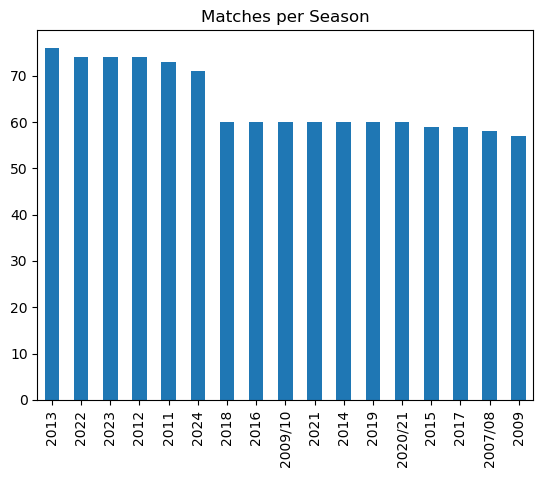

In [16]:
matches["season"].value_counts().plot(kind="bar")
plt.title("Matches per Season")
plt.show()

In [17]:
mi_matches = matches[(matches["team1"] == "Mumbai Indians") | (matches["team2"] == "Mumbai Indians")]

In [18]:
mi_matches["season"].value_counts()

2013       19
2012       17
2017       17
2023       16
2009/10    16
2019       16
2020/21    16
2015       16
2011       16
2014       15
2024       14
2007/08    14
2022       14
2018       14
2016       14
2021       14
2009       13
Name: season, dtype: int64

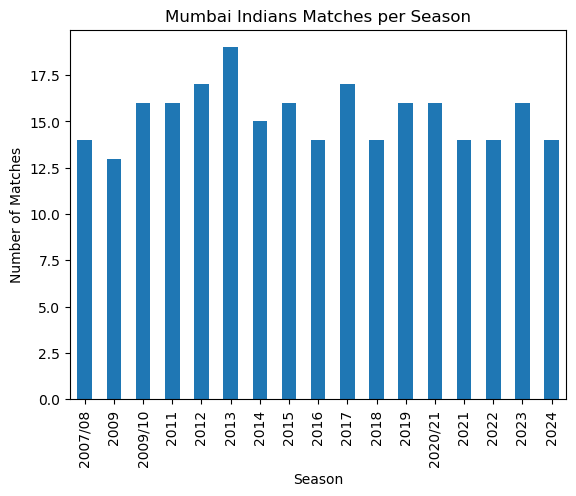

In [19]:
mi_matches["season"].value_counts().sort_index().plot(kind="bar")

plt.title("Mumbai Indians Matches per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.show()

In [20]:
matches["winner"] == "Mumbai Indians"

0       False
1       False
2       False
3       False
4       False
        ...  
1090    False
1091    False
1092    False
1093    False
1094    False
Name: winner, Length: 1095, dtype: bool

In [21]:
mi_wins = matches[matches["winner"] == "Mumbai Indians"]

In [22]:
mi_wins["season"].value_counts()

2013       13
2017       12
2009/10    11
2019       11
2020/21    11
2012       10
2011       10
2015       10
2023        9
2014        7
2007/08     7
2021        7
2016        7
2018        6
2009        5
2024        4
2022        4
Name: season, dtype: int64

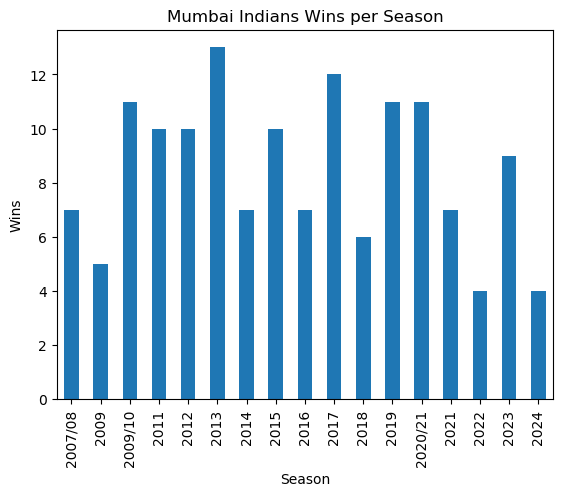

In [23]:
mi_wins["season"].value_counts().sort_index().plot(kind="bar")

plt.title("Mumbai Indians Wins per Season")
plt.xlabel("Season")
plt.ylabel("Wins")
plt.show()

In [24]:
matches_played = mi_matches["season"].value_counts().sort_index()
matches_won = mi_wins["season"].value_counts().sort_index()

win_percentage = (matches_won / matches_played) * 100

In [25]:
win_percentage

2007/08    50.000000
2009       38.461538
2009/10    68.750000
2011       62.500000
2012       58.823529
2013       68.421053
2014       46.666667
2015       62.500000
2016       50.000000
2017       70.588235
2018       42.857143
2019       68.750000
2020/21    68.750000
2021       50.000000
2022       28.571429
2023       56.250000
2024       28.571429
Name: season, dtype: float64

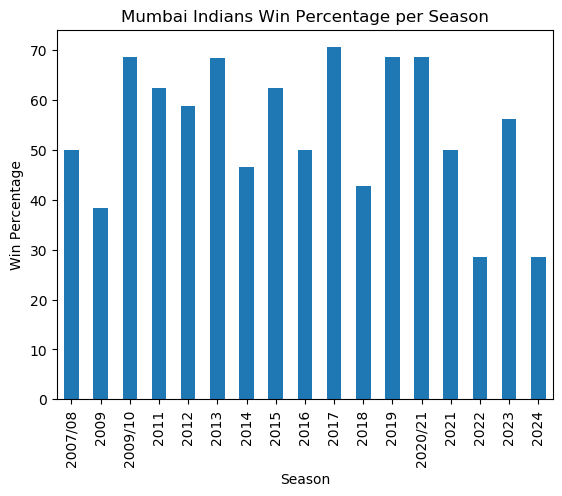

In [26]:
win_percentage.plot(kind="bar")

plt.title("Mumbai Indians Win Percentage per Season")
plt.xlabel("Season")
plt.ylabel("Win Percentage")
plt.show()

In [27]:
deliveries.groupby("batter")

In [28]:
deliveries.groupby("batter")["batsman_runs"].sum()

batter
A Ashish Reddy     280
A Badoni           634
A Chandila           4
A Chopra            53
A Choudhary         25
                  ... 
Yashpal Singh       47
Younis Khan          3
Yudhvir Singh       22
Yuvraj Singh      2754
Z Khan             117
Name: batsman_runs, Length: 673, dtype: int64

In [29]:
deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False)

batter
V Kohli         8014
S Dhawan        6769
RG Sharma       6630
DA Warner       6567
SK Raina        5536
                ... 
JL Denly           0
S Ladda            0
YA Abdulla         0
Abdur Razzak       0
IC Pandey          0
Name: batsman_runs, Length: 673, dtype: int64

In [30]:
top_batsmen = deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(10)
top_batsmen

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

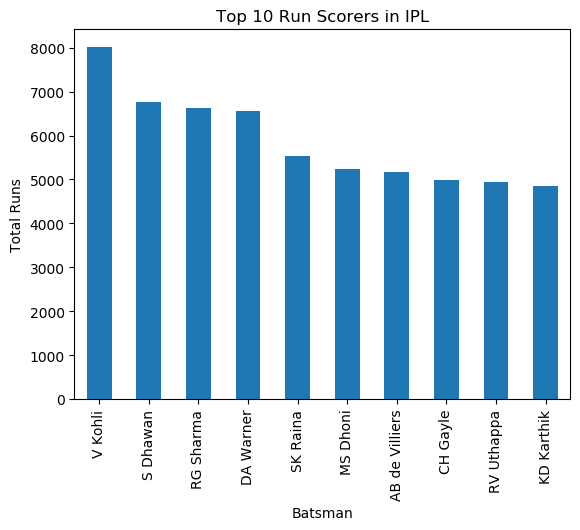

In [31]:
top_batsmen.plot(kind="bar")

plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Batsman")
plt.ylabel("Total Runs")
plt.show()

In [32]:
deliveries[deliveries["is_wicket"] == 1].groupby("bowler")["is_wicket"].count()

bowler
A Ashish Reddy     19
A Badoni            2
A Chandila         11
A Choudhary         5
A Flintoff          2
                 ... 
Yash Dayal         31
Yash Thakur        27
Yudhvir Singh       4
Yuvraj Singh       39
Z Khan            119
Name: is_wicket, Length: 455, dtype: int64

In [33]:
wickets = deliveries[deliveries["is_wicket"] == 1]

top_bowlers = wickets.groupby("bowler")["is_wicket"].count().sort_values(ascending=False).head(10)

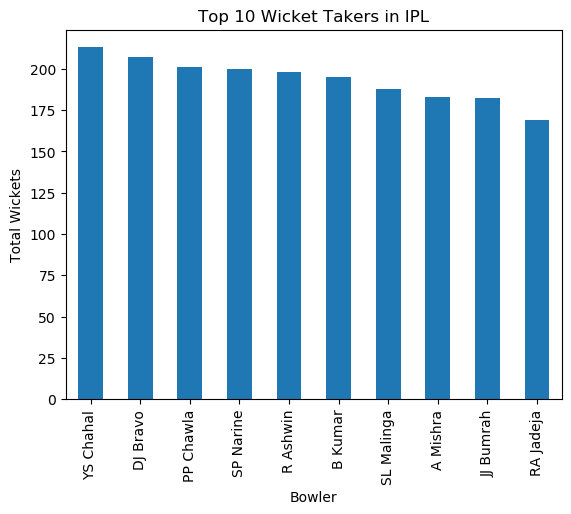

In [34]:
top_bowlers.plot(kind="bar")

plt.title("Top 10 Wicket Takers in IPL")
plt.xlabel("Bowler")
plt.ylabel("Total Wickets")
plt.show()

In [35]:
deliveries.groupby("batter")["ball"].count()

batter
A Ashish Reddy     196
A Badoni           505
A Chandila           7
A Chopra            75
A Choudhary         20
                  ... 
Yashpal Singh       67
Younis Khan          7
Yudhvir Singh       16
Yuvraj Singh      2207
Z Khan             141
Name: ball, Length: 673, dtype: int64

In [36]:
runs = deliveries.groupby("batter")["batsman_runs"].sum()

In [37]:
balls = deliveries.groupby("batter")["ball"].count()

In [38]:
batsman_stats = pd.DataFrame({
    "runs": runs,
    "balls": balls
})

In [39]:
batsman_stats = batsman_stats[batsman_stats["balls"] >= 2000]

In [40]:
batsman_stats["strike_rate"] = (batsman_stats["runs"] / batsman_stats["balls"]) * 100

In [41]:
batsman_stats.sort_values("strike_rate", ascending=False).head(10)

,runs,balls,strike_rate
batter,,,
AB de Villiers,5181,3487,148.580442
RR Pant,3297,2296,143.597561
SA Yadav,3594,2522,142.505948
JC Buttler,3583,2519,142.238984
CH Gayle,4997,3516,142.121729
KA Pollard,3437,2447,140.457703
YK Pathan,3222,2334,138.046272
DA Warner,6567,4849,135.429986
SV Samson,4419,3270,135.137615


In [42]:
top_sr = batsman_stats.sort_values("strike_rate", ascending=False).head(10)

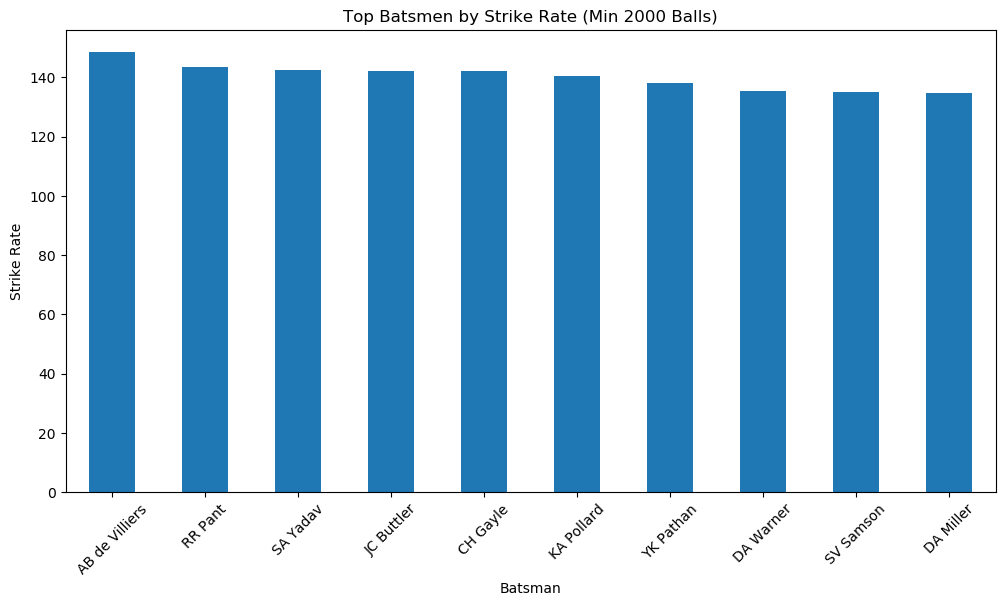

In [43]:
plt.figure(figsize=(12,6))

top_sr["strike_rate"].plot(kind="bar")

plt.title("Top Batsmen by Strike Rate (Min 2000 Balls)")
plt.xlabel("Batsman")
plt.ylabel("Strike Rate")

plt.xticks(rotation=45)
plt.show()

In [44]:
sixes = deliveries[deliveries["batsman_runs"] == 6]

top_six = sixes.groupby("batter")["batsman_runs"].count().sort_values(ascending=False).head(10)

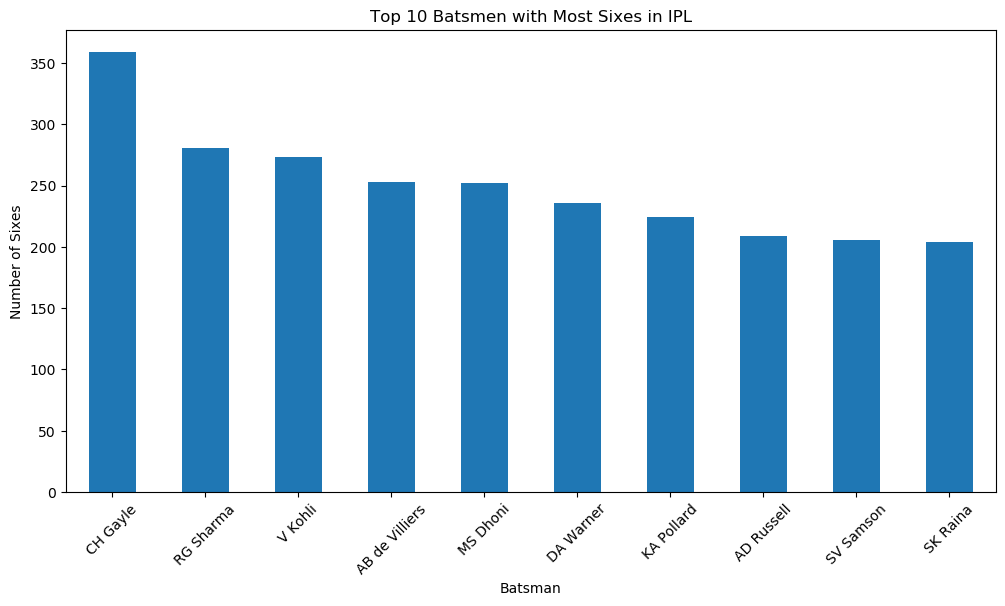

In [45]:
plt.figure(figsize=(12,6))
top_six.plot(kind="bar")

plt.title("Top 10 Batsmen with Most Sixes in IPL")
plt.xlabel("Batsman")
plt.ylabel("Number of Sixes")

plt.xticks(rotation=45)
plt.show()

In [46]:
fours = deliveries[deliveries["batsman_runs"] == 4]

In [47]:
top_fours = fours.groupby("batter")["batsman_runs"].count().sort_values(ascending=False).head(10)

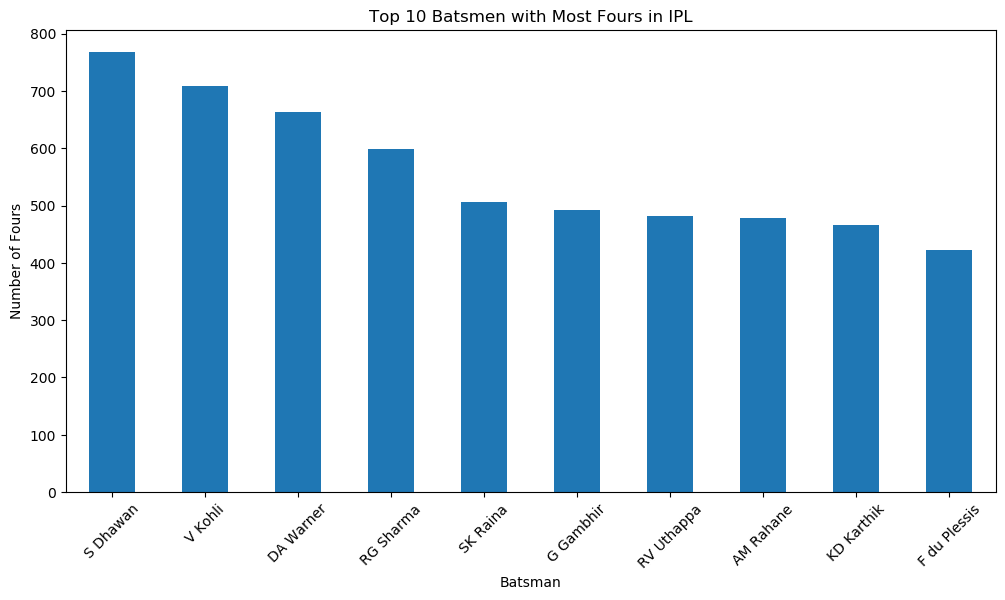

In [48]:
plt.figure(figsize=(12,6))

top_fours.plot(kind="bar")

plt.title("Top 10 Batsmen with Most Fours in IPL")
plt.xlabel("Batsman")
plt.ylabel("Number of Fours")

plt.xticks(rotation=45)

plt.show()

In [49]:
runs_conceded = deliveries.groupby("bowler")["total_runs"].sum()

In [50]:
balls_bowled = deliveries.groupby("bowler")["ball"].count()

In [51]:
bowler_stats = pd.DataFrame({
    "runs": runs_conceded,
    "balls": balls_bowled
})

In [52]:
bowler_stats = bowler_stats[bowler_stats["balls"] >= 500]

In [53]:
bowler_stats["economy"] = (bowler_stats["runs"] / bowler_stats["balls"]) * 6

In [54]:
best_economy = bowler_stats.sort_values("economy").head(10)

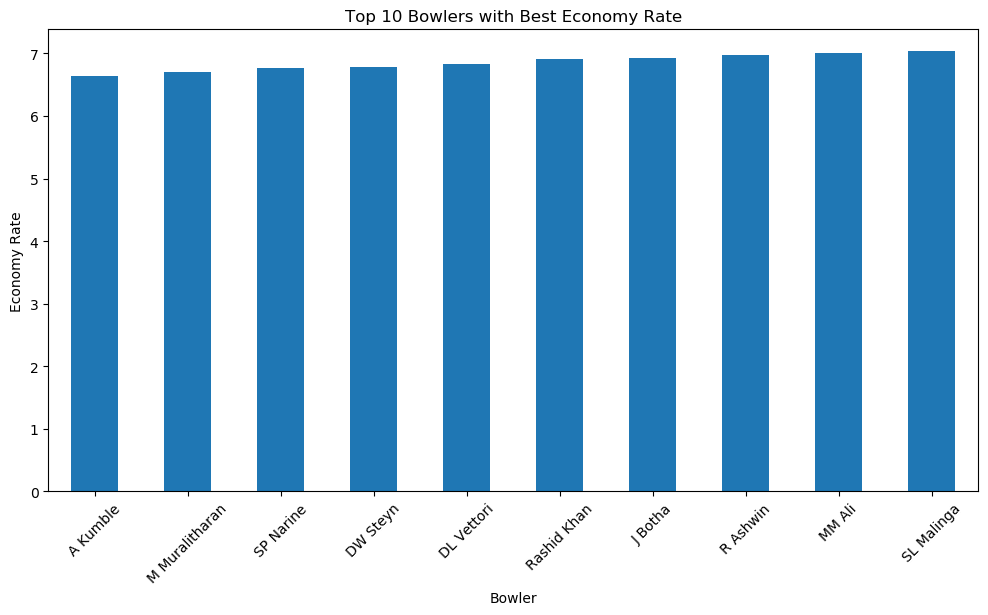

In [55]:
plt.figure(figsize=(12,6))

best_economy["economy"].plot(kind="bar")

plt.title("Top 10 Bowlers with Best Economy Rate")
plt.xlabel("Bowler")
plt.ylabel("Economy Rate")

plt.xticks(rotation=45)
plt.show()

In [56]:
(matches["toss_winner"] == matches["winner"]).sum()

554

In [57]:
toss_win_match = (matches["toss_winner"] == matches["winner"]).sum()

total_matches = matches.shape[0]

toss_win_percentage = (toss_win_match / total_matches) * 100

toss_win_percentage

50.593607305936075

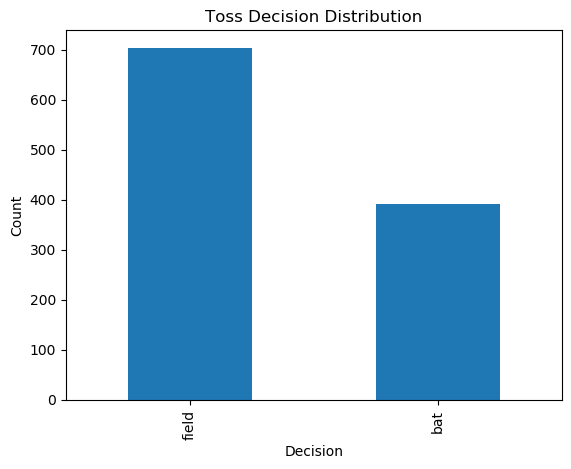

In [58]:
matches["toss_decision"].value_counts().plot(kind="bar")

plt.title("Toss Decision Distribution")
plt.xlabel("Decision")
plt.ylabel("Count")

plt.show()

In [59]:
matches["toss_winner"].value_counts()

Mumbai Indians                 143
Chennai Super Kings            122
Kolkata Knight Riders          122
Rajasthan Royals               120
Royal Challengers Bangalore    113
Sunrisers Hyderabad             88
Kings XI Punjab                 85
Delhi Daredevils                80
Delhi Capitals                  50
Deccan Chargers                 43
Punjab Kings                    24
Gujarat Titans                  22
Pune Warriors                   20
Lucknow Super Giants            19
Gujarat Lions                   15
Kochi Tuskers Kerala             8
Royal Challengers Bengaluru      8
Rising Pune Supergiants          7
Rising Pune Supergiant           6
Name: toss_winner, dtype: int64

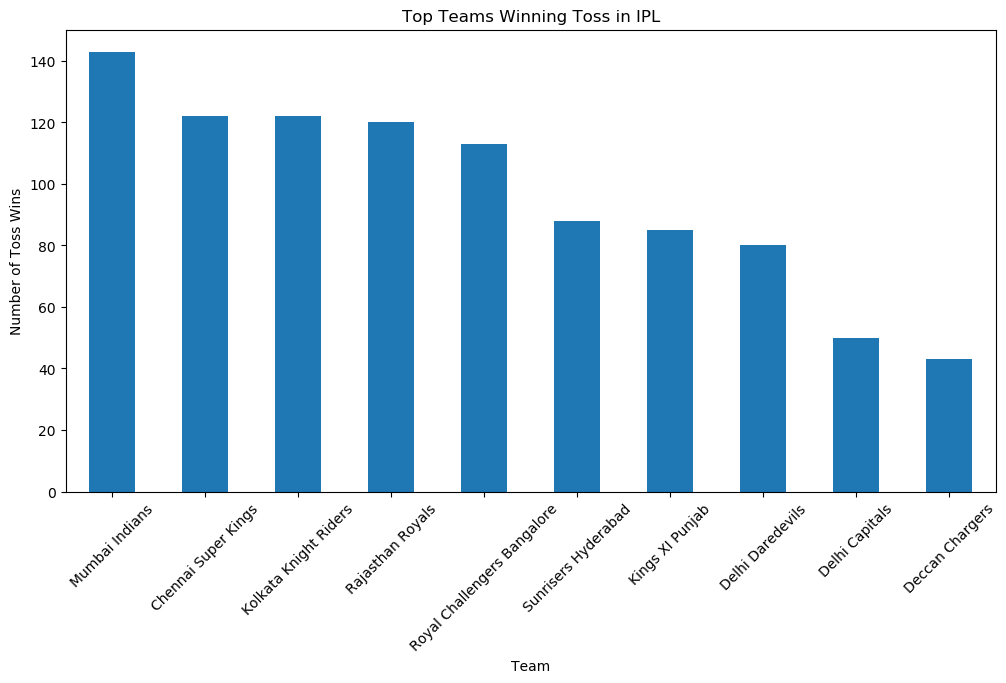

In [60]:
plt.figure(figsize=(12,6))

matches["toss_winner"].value_counts().head(10).plot(kind="bar")

plt.title("Top Teams Winning Toss in IPL")
plt.xlabel("Team")
plt.ylabel("Number of Toss Wins")

plt.xticks(rotation=45)
plt.show()

In [61]:
ipl = deliveries.merge(matches[["id","season"]], left_on="match_id", right_on="id")

In [62]:
season_runs = ipl.groupby("season")["total_runs"].sum()

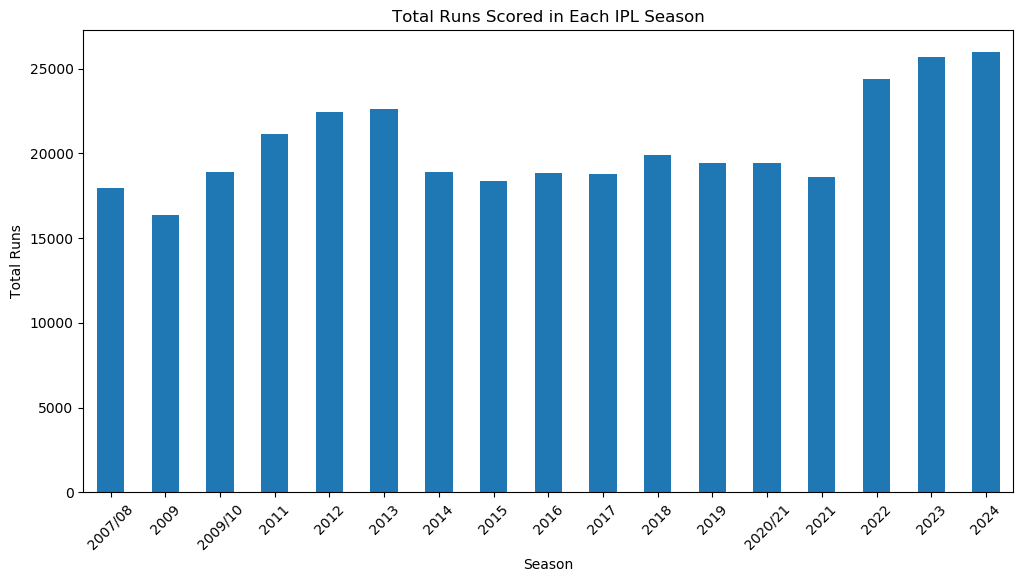

In [63]:
plt.figure(figsize=(12,6))

season_runs.plot(kind="bar")

plt.title("Total Runs Scored in Each IPL Season")
plt.xlabel("Season")
plt.ylabel("Total Runs")

plt.xticks(rotation=45)
plt.show()

In [64]:
death_overs = deliveries[deliveries["over"] >= 16]

In [65]:
death_runs = death_overs.groupby("batter")["batsman_runs"].sum()

In [66]:
top_death_batsmen = death_runs.sort_values(ascending=False).head(10)

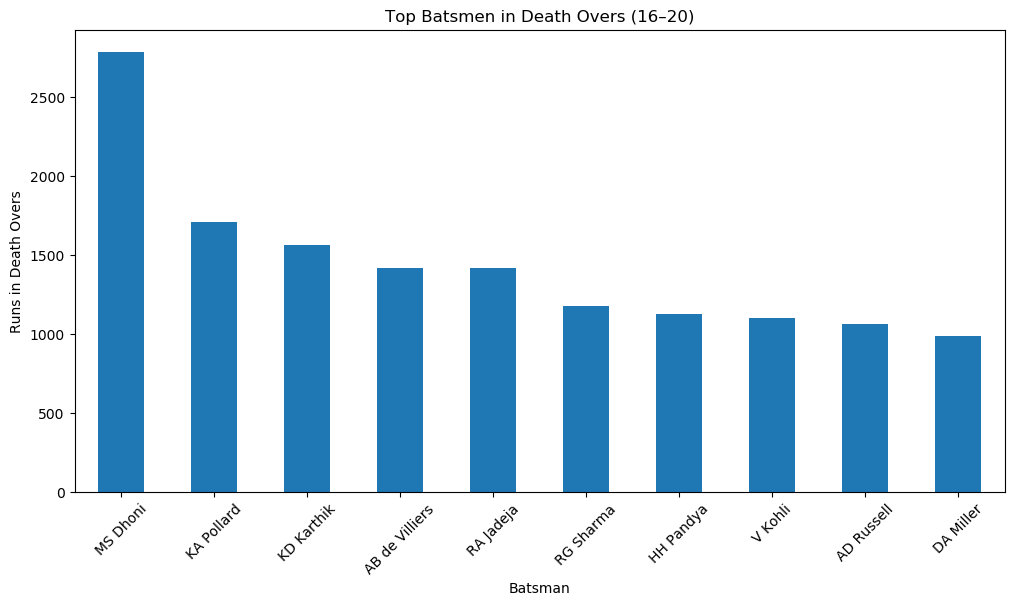

In [67]:
plt.figure(figsize=(12,6))

top_death_batsmen.plot(kind="bar")

plt.title("Top Batsmen in Death Overs (16–20)")
plt.xlabel("Batsman")
plt.ylabel("Runs in Death Overs")

plt.xticks(rotation=45)
plt.show()

In [68]:
match_runs = deliveries.groupby("match_id")["total_runs"].sum()

avg_runs = match_runs.mean()

avg_runs

317.5853881278539

In [69]:
venue_counts = matches["venue"].value_counts().head(10)

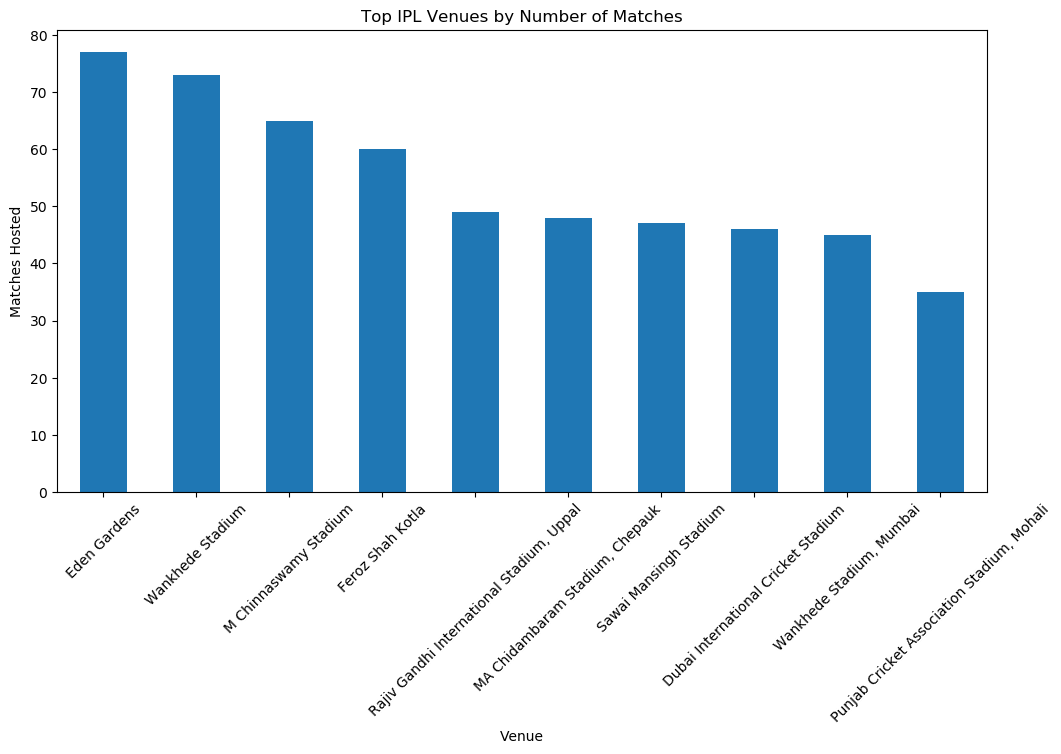

In [70]:
plt.figure(figsize=(12,6))

venue_counts.plot(kind="bar")

plt.title("Top IPL Venues by Number of Matches")
plt.xlabel("Venue")
plt.ylabel("Matches Hosted")

plt.xticks(rotation=45)
plt.show()

In [71]:
pom = matches["player_of_match"].value_counts().head(10)

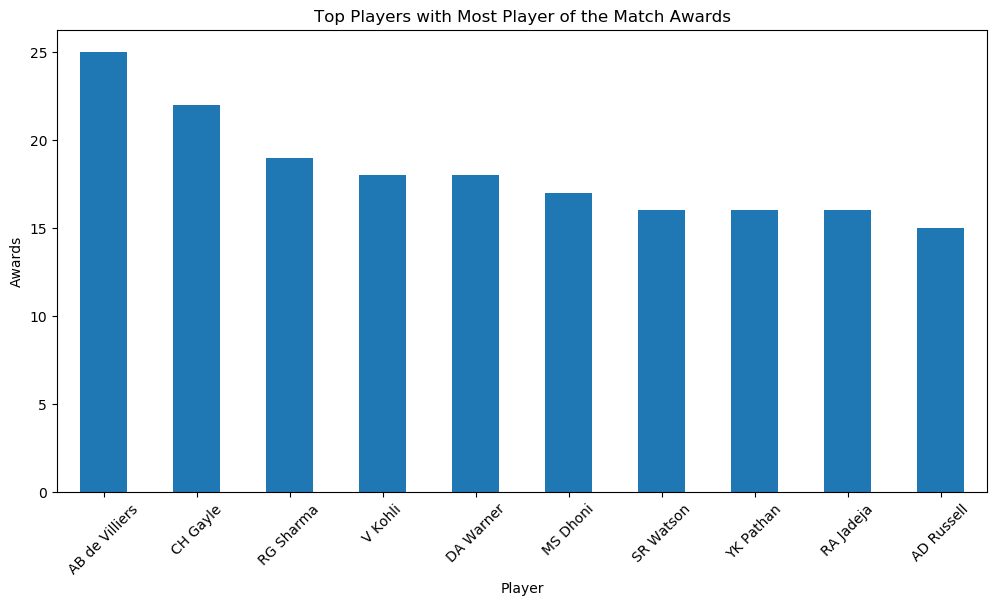

In [72]:
plt.figure(figsize=(12,6))

pom.plot(kind="bar")

plt.title("Top Players with Most Player of the Match Awards")
plt.xlabel("Player")
plt.ylabel("Awards")

plt.xticks(rotation=45)
plt.show()

In [73]:
data = matches[['city','team1','team2','toss_winner','toss_decision','winner']]

In [74]:
data.head()

,city,team1,team2,toss_winner,toss_decision,winner
0,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders
1,Chandigarh,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings
2,Delhi,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils
3,Mumbai,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore
4,Kolkata,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders


In [75]:
data.isnull().sum()

city             0
team1            0
team2            0
toss_winner      0
toss_decision    0
winner           5
dtype: int64

In [76]:
data.dropna(inplace=True)

C:\Users\HP\anaconda3\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [77]:
data.isnull().sum()

city             0
team1            0
team2            0
toss_winner      0
toss_decision    0
winner           0
dtype: int64

In [78]:
data = pd.get_dummies(data, columns=['city','team1','team2','toss_winner','toss_decision'])

In [79]:
X = data.drop("winner", axis=1)
y = data["winner"]

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [81]:
X_train.shape
X_test.shape

(218, 96)

In [82]:
from sklearn.linear_model import LogisticRegression

In [83]:
model = LogisticRegression()

In [84]:
model.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [85]:
y_pred = model.predict(X_test)

In [86]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.5596330275229358

In [87]:
ipl = deliveries.merge(matches[['id','winner']], left_on='match_id', right_on='id')

In [88]:
ipl = ipl[ipl['inning'] == 2]

In [89]:
ipl['current_score'] = ipl.groupby('match_id')['total_runs'].cumsum()

In [90]:
ipl['balls_left'] = 120 - (ipl['over']*6 + ipl['ball'])

In [91]:
ipl['wickets_left'] = 10 - ipl.groupby('match_id')['is_wicket'].cumsum()

In [92]:
target = deliveries.groupby(['match_id','inning'])['total_runs'].sum().reset_index()

In [93]:
target = target[target['inning'] == 1]

In [94]:
target['target'] = target['total_runs'] + 1

In [95]:
ipl = ipl.merge(target[['match_id','target']], on='match_id')

In [96]:
ipl['runs_left'] = ipl['target'] - ipl['current_score']

In [97]:
ipl['rrr'] = (ipl['runs_left'] * 6) / ipl['balls_left']

In [98]:
ipl['crr'] = ipl['current_score'] / ((120 - ipl['balls_left']) / 6)

ipl['crr'] = ipl['crr'].replace([np.inf, -np.inf], 0)

ipl['rrr_crr_diff'] = ipl['rrr'] - ipl['crr']

In [99]:
ipl.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder', 'id', 'winner', 'current_score',
       'balls_left', 'wickets_left', 'target', 'runs_left', 'rrr', 'crr',
       'rrr_crr_diff'],
      dtype='object')

In [100]:
ipl = deliveries.merge(matches[['id','winner','city']], 
                       left_on='match_id', right_on='id')

ipl = ipl[ipl['inning'] == 2]

ipl['current_score'] = ipl.groupby('match_id')['total_runs'].cumsum()

ipl['balls_left'] = 120 - (ipl['over']*6 + ipl['ball'])

ipl['wickets_left'] = 10 - ipl.groupby('match_id')['is_wicket'].cumsum()

In [101]:
target = deliveries.groupby(['match_id','inning'])['total_runs'].sum().reset_index()
target = target[target['inning'] == 1]
target['target'] = target['total_runs'] + 1

ipl = ipl.merge(target[['match_id','target']], on='match_id')

In [102]:
ipl.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder', 'id', 'winner', 'city', 'current_score',
       'balls_left', 'wickets_left', 'target'],
      dtype='object')

In [103]:
ipl['result'] = (ipl['batting_team'] == ipl['winner']).astype(int)

In [104]:
ipl['runs_left'] = ipl['target'] - ipl['current_score']

ipl['rrr'] = (ipl['runs_left'] * 6) / ipl['balls_left']

ipl['crr'] = ipl['current_score'] / ((120 - ipl['balls_left']) / 6)

# handle infinity
ipl['rrr'] = ipl['rrr'].replace([np.inf, -np.inf], 0)
ipl['crr'] = ipl['crr'].replace([np.inf, -np.inf], 0)

In [105]:
ipl = ipl.replace([np.inf, -np.inf], np.nan)

ipl = ipl.dropna(subset=[
    'batting_team','bowling_team','city',
    'runs_left','balls_left','wickets_left','target','rrr'
])

In [106]:
ipl['crr'] = ipl['current_score'] / ((120 - ipl['balls_left']) / 6)

In [107]:
X = ipl[['batting_team','bowling_team','city',
         'runs_left','balls_left','wickets_left','crr','rrr']]


y = ipl['result']

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [108]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [109]:
trf = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'),
     ['batting_team','bowling_team','city']),
    
    ('num', StandardScaler(),
     ['balls_left','wickets_left','crr'])
])

In [110]:
from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline([
    ('step1', trf),
    ('step2', RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42))
])

In [111]:
pipe.fit(X_train, y_train)

Pipeline(memory=None,
         steps=[('step1',
                 ColumnTransformer(n_jobs=None, remainder='drop',
                                   sparse_threshold=0.3,
                                   transformer_weights=None,
                                   transformers=[('cat',
                                                  OneHotEncoder(categories='auto',
                                                                drop=None,
                                                                dtype=<class 'numpy.float64'>,
                                                                handle_unknown='ignore',
                                                                sparse=True),
                                                  ['batting_team',
                                                   'bowling_team', 'city']),
                                                 ('num',
                                                  StandardScaler(copy=True,
              

In [112]:
from sklearn.metrics import accuracy_score

y_pred = pipe.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6999403459932392


In [113]:
y_pred = pipe.predict(X_test)

In [114]:
pipe.predict_proba(X_test)

array([[0.41809206, 0.58190794],
       [0.4550178 , 0.5449822 ],
       [0.41410102, 0.58589898],
       ...,
       [0.41356946, 0.58643054],
       [0.489429  , 0.510571  ],
       [0.47799266, 0.52200734]])

In [115]:
pipe.predict_proba(X_test)[0]

array([0.41809206, 0.58190794])

In [116]:
probs = pipe.predict_proba(X_test)

win_probs = probs[:, 1]   # probability of winning

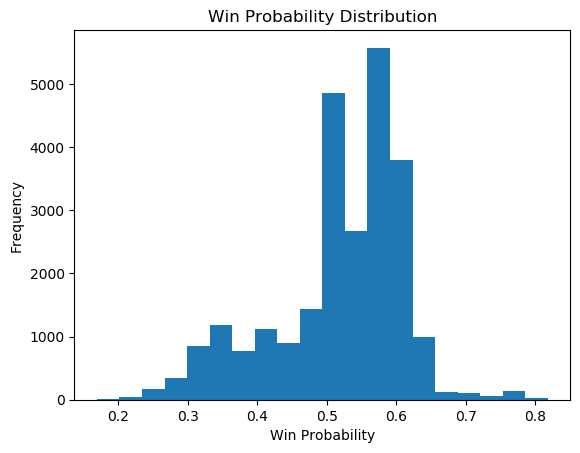

In [117]:
import matplotlib.pyplot as plt

plt.hist(win_probs, bins=20)
plt.title("Win Probability Distribution")
plt.xlabel("Win Probability")
plt.ylabel("Frequency")
plt.show()

In [118]:
ipl['match_id'].value_counts()

1359480    136
829737     134
829811     134
1426268    133
1370350    132
          ... 
980989      34
392183      32
733993      30
1178424     20
829813       7
Name: match_id, Length: 1092, dtype: int64

In [119]:
match_id = ipl['match_id'].unique()[0]
match_df = ipl[ipl['match_id'] == match_id]

In [120]:
match_X = match_df[['batting_team','bowling_team','city',
                    'runs_left','balls_left','wickets_left','crr','rrr']]

In [121]:
match_df['win_prob'] = pipe.predict_proba(match_X)[:,1]

C:\Users\HP\anaconda3\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


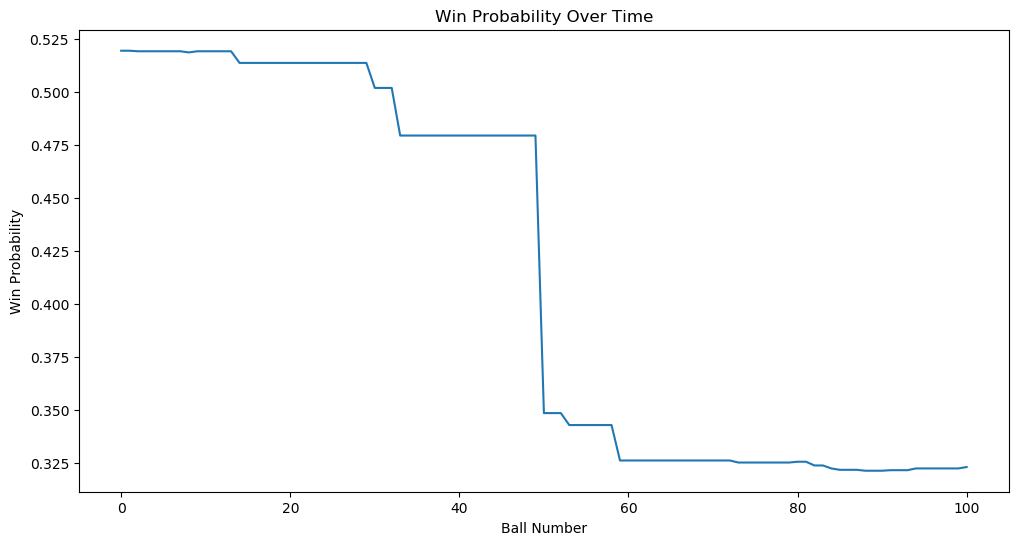

In [122]:
plt.figure(figsize=(12,6))
plt.plot(match_df['win_prob'])
plt.title("Win Probability Over Time")
plt.xlabel("Ball Number")
plt.ylabel("Win Probability")
plt.show()

In [123]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_pipe = Pipeline([
    ('step1', trf),
    ('step2', rf)
])

rf_pipe.fit(X_train, y_train)

y_pred_rf = rf_pipe.predict(X_test)

In [124]:
from sklearn.metrics import accuracy_score

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.7511234837939949


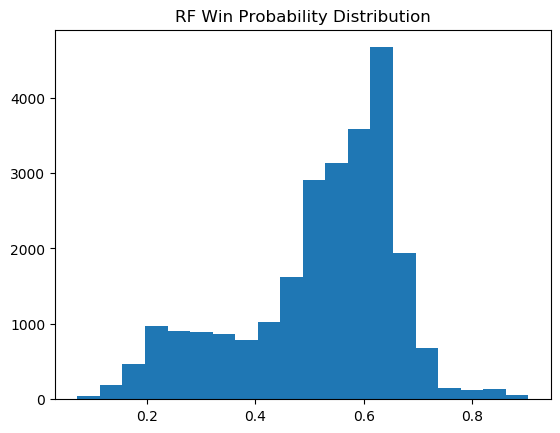

In [125]:
probs = rf_pipe.predict_proba(X_test)
win_probs = probs[:,1]

plt.hist(win_probs, bins=20)
plt.title("RF Win Probability Distribution")
plt.show()

In [126]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ('step1', trf),
    ('step2', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [127]:
pipe_rf.fit(X_train, y_train)

Pipeline(memory=None,
         steps=[('step1',
                 ColumnTransformer(n_jobs=None, remainder='drop',
                                   sparse_threshold=0.3,
                                   transformer_weights=None,
                                   transformers=[('cat',
                                                  OneHotEncoder(categories='auto',
                                                                drop=None,
                                                                dtype=<class 'numpy.float64'>,
                                                                handle_unknown='ignore',
                                                                sparse=True),
                                                  ['batting_team',
                                                   'bowling_team', 'city']),
                                                 ('num',
                                                  StandardScaler(copy=True,
              

In [128]:
y_pred_rf = rf_pipe.predict(X_test)

In [129]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7511234837939949


In [130]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [131]:
from xgboost import XGBClassifier

pipe = Pipeline([
    ('step1', trf),
    ('step2', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

from sklearn.metrics import accuracy_score
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))

XGBoost Accuracy: 0.8344004772320541


In [132]:
match_ids = ipl['match_id'].unique()


In [133]:
from sklearn.model_selection import train_test_split

train_ids, test_ids = train_test_split(
    match_ids, test_size=0.2, random_state=42
)

In [134]:
train_df = ipl[ipl['match_id'].isin(train_ids)]

In [135]:
test_df = ipl[ipl['match_id'].isin(test_ids)]

In [136]:
X_train = train_df[['batting_team','bowling_team','city',
                    'balls_left','wickets_left','crr']]

In [137]:
y_train = train_df['result']

In [138]:
X_test = test_df[['batting_team','bowling_team','city',
                  'balls_left','wickets_left','crr']]

y_test = test_df['result']

In [139]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

trf = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'),
     ['batting_team','bowling_team','city']),
    
    ('num', StandardScaler(),
     ['balls_left','wickets_left','crr'])
])

In [140]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline([
    ('step1', trf),
    ('step2', RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)
    )
])

In [141]:
pipe.fit(X_train, y_train)

Pipeline(memory=None,
         steps=[('step1',
                 ColumnTransformer(n_jobs=None, remainder='drop',
                                   sparse_threshold=0.3,
                                   transformer_weights=None,
                                   transformers=[('cat',
                                                  OneHotEncoder(categories='auto',
                                                                drop=None,
                                                                dtype=<class 'numpy.float64'>,
                                                                handle_unknown='ignore',
                                                                sparse=True),
                                                  ['batting_team',
                                                   'bowling_team', 'city']),
                                                 ('num',
                                                  StandardScaler(copy=True,
              

In [142]:
y_pred = pipe.predict(X_test)

In [143]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7264286283573763


In [144]:
probs = pipe.predict_proba(X_test)
win_probs = probs[:,1]

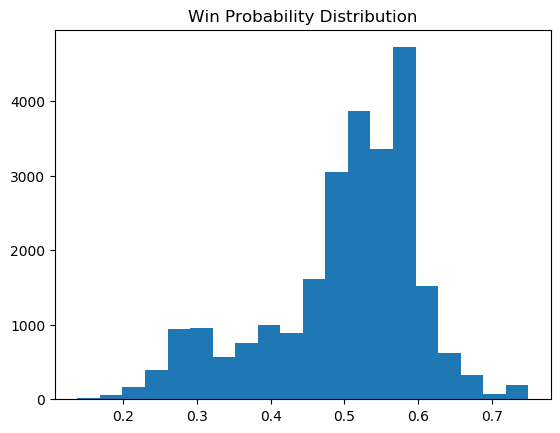

In [145]:
import matplotlib.pyplot as plt

plt.hist(win_probs, bins=20)
plt.title("Win Probability Distribution")
plt.show()

In [146]:
ohe = pipe.named_steps['step1'].named_transformers_['cat']

cat_features = ohe.get_feature_names(['batting_team','bowling_team','city'])

In [147]:
num_features = ['balls_left','wickets_left','crr']

In [148]:
feature_names = list(cat_features) + num_features

In [149]:
import pandas as pd

importances = pipe.named_steps['step2'].feature_importances_

feature_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feature_df = feature_df.sort_values('importance', ascending=False)

feature_df.head(10)

,feature,importance
76,wickets_left,0.342079
77,crr,0.129878
75,balls_left,0.051543
23,bowling_team_Gujarat Lions,0.034045
46,city_Chennai,0.024451
28,bowling_team_Lucknow Super Giants,0.023440
11,batting_team_Pune Warriors,0.020057
56,city_Jaipur,0.019201
29,bowling_team_Mumbai Indians,0.019156
5,batting_team_Gujarat Titans,0.018197


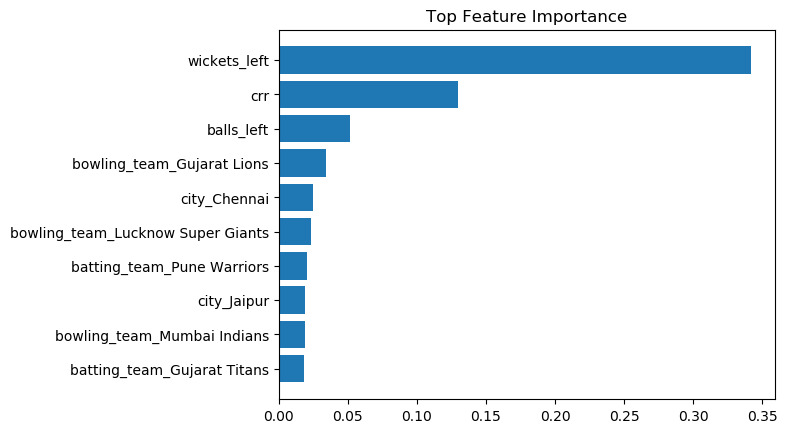

In [150]:
import matplotlib.pyplot as plt

top_features = feature_df.head(10)

plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Feature Importance")
plt.show()

In [151]:
import pickle
pickle.dump(pipe, open('ipl_model.pkl', 'wb'))

In [152]:
import pandas as pd

sample = pd.DataFrame({
    'batting_team': ['Mumbai Indians'],
    'bowling_team': ['Chennai Super Kings'],
    'city': ['Mumbai'],
    'balls_left': [30],
    'wickets_left': [6],
    'crr': [8.5]
})

pipe.predict_proba(sample)

array([[0.46754747, 0.53245253]])

In [153]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.
